# Population Analysis

In [142]:
import pandas as pd
import matplotlib.pyplot as plt

## Load dataset from the CSO API

In [143]:
url = "https://ws.cso.ie/public/api.restful/PxStat.Data.Cube_API.ReadDataset/FY006A/CSV/1.0/en"
df = pd.read_csv(url)

df.tail(3)

,STATISTIC,Statistic Label,TLIST(A1),CensusYear,C02199V02655,Sex,C02076V03371,Single Year of Age,C03789V04537,Administrative Counties,UNIT,VALUE
9789,FY006AC01,Population,2022,2022,2,Female,650,100 years and over,2ae19629-149d-13a3-e055-000000000001,Cavan County Council,Number,12
9790,FY006AC01,Population,2022,2022,2,Female,650,100 years and over,2ae19629-14a4-13a3-e055-000000000001,Donegal County Council,Number,31
9791,FY006AC01,Population,2022,2022,2,Female,650,100 years and over,2ae19629-1495-13a3-e055-000000000001,Monaghan County Council,Number,7


## Prepare data

### Remove unnecesary columns

In [144]:
# Check headers
headers = df.columns.tolist()

headers

['STATISTIC',
 'Statistic Label',
 'TLIST(A1)',
 'CensusYear',
 'C02199V02655',
 'Sex',
 'C02076V03371',
 'Single Year of Age',
 'C03789V04537',
 'Administrative Counties',
 'UNIT',
 'VALUE']

In [145]:
# Drop columns that are not needed for analysis
drop_col_list = ['STATISTIC', 'Statistic Label','TLIST(A1)','CensusYear','C02199V02655','C02076V03371','C03789V04537','UNIT'] 
df.drop(columns=drop_col_list, inplace=True)

print (df.head(3))

          Sex Single Year of Age Administrative Counties    VALUE
0  Both sexes           All ages                 Ireland  5149139
1  Both sexes           All ages   Carlow County Council    61968
2  Both sexes           All ages     Dublin City Council   592713


### Format age values
- Remove "All ages" rows
- Convert “Under 1 year” to 0
- Strip non-digit characters
- Convert age values to integers

This ensures we can perform numeric filtering and grouping.

In [146]:
# Remove "All ages" rows
df = df[df["Single Year of Age"] != 'All ages']

# Convert "Under 1 year" to "0"
df["Single Year of Age"] = df["Single Year of Age"].str.replace("Under 1 year","0")

# Replace non-digit characters with an empty string
df["Single Year of Age"] = df["Single Year of Age"].str.replace("\D", "", regex=True)

df.head(3)

,Sex,Single Year of Age,Administrative Counties,VALUE
32,Both sexes,0,Ireland,57796
33,Both sexes,0,Carlow County Council,699
34,Both sexes,0,Dublin City Council,6213


In [147]:
# Convert age values to integers
df["Single Year of Age"] = df["Single Year of Age"].astype(int)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9696 entries, 32 to 9791
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Sex                      9696 non-null   object
 1   Single Year of Age       9696 non-null   int64 
 2   Administrative Counties  9696 non-null   object
 3   VALUE                    9696 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 378.8+ KB


### Filter by sex and region
For **Parts 1** and **2**, restrict the dataset to:

- Sex: Male, Female
- Administrative Counties == "Ireland"

In [148]:
# Remove "Both sexes" rows
df = df[df['Sex'] != 'Both sexes']

# Filter out individual counties
df_irl = df[df['Administrative Counties'] == 'Ireland']

df_irl.head(3)

,Sex,Single Year of Age,Administrative Counties,VALUE
3296,Male,0,Ireland,29610
3328,Male,1,Ireland,28875
3360,Male,2,Ireland,30236


# Part 1 — Weighted Mean Age & Differences by Sex

## Weighted Mean Age By Sex

To estimate the weighted mean age for each sex, I used the standard formula from Lecture 5:
> Σ(age * population at that age) / Σ(populations at age)

I initially considered computing this manually for each sex usinng [numpy.average()](https://numpy.org/devdocs/reference/generated/numpy.average.html), but the apprach seemed manual. After further research, I adopted a cleaner method demonstrated in [Python & VBA](https://pythonandvba.com/blog/weighted-average-calculation-in-pandas/) tutorial using `groupby.()` function.

In [149]:
# Create a function to calculate weighted average
# The function takes three arguments: values, ages, sex
def calc_weighted_avg(values, ages, sex): 

    # Calculate weighted values multiplying ages by number of population at that age
    weighted = ages * values
    
    # Return calculated of the weighted average by sex
    return weighted.groupby(sex).sum() / values.groupby(sex).sum()

# Call the function
calc_weighted_avg(df_irl['VALUE'], df_irl['Single Year of Age'], df_irl['Sex'])

Sex
Female    38.939796
Male      37.739448
dtype: float64

From this calculation, the female weighted mean age is approximately 38.94, which is higher than the male weighted mean age of about 37.74

## Population Differences By Age
To examine differences by sex and age, I reshaped the dataset using `pd.pivot_table()`. I used the format that places ages as the index and separates male and female population into individual columns. 

This approach follows the logic used in lecture materials as well as a tutorial from [Geeks for Geeks](https://www.geeksforgeeks.org/python/python-pandas-pivot_table/) on pivoting data in Pandas.

### Pivot data for further analysis

In [150]:
df_analysis = pd.pivot_table(df_irl, values = 'VALUE', index='Single Year of Age', columns = 'Sex')

df_analysis.head(3)

Sex,Female,Male
Single Year of Age,,
0,28186,29610
1,27545,28875
2,28974,30236


### Add a new column (Male minus Female)
This highlights where one sex has higher population counts at each age and by how much.

In [151]:
# Create a new column to show the difference between male and female populations at each age
df_analysis['Population Diff At Age'] = df_analysis['Male'] - df_analysis['Female']

# Convert the 'Population Diff At Age' column to integer type
df_analysis['Population Diff At Age'] = df_analysis['Population Diff At Age'].astype(int)

df_analysis.head(3)

Sex,Female,Male,Population Diff At Age
Single Year of Age,,,
0,28186,29610,1424
1,27545,28875,1330
2,28974,30236,1262


### Visualize data
I chose clusterred bar plot (side-by-side bars for male and female values) to illustrate the population distribution by age for each sex. I experimented with stacked bar charts initially, but they made it difficult to compare the male and female populations at each age. Swapping to a clustered bar plot significantly improved visibility.

For plotting, I used various resources, including:
- `Matplotlib` library (imported in the beginning of the notebook), and the official [Matplotlib](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html) documentation on bar plots.
- [Geek for Geeks](https://www.geeksforgeeks.org/python/create-a-grouped-bar-plot-in-matplotlib/) tutorial on grouped bar plots.
- ChatGPT for debugging and fixes.

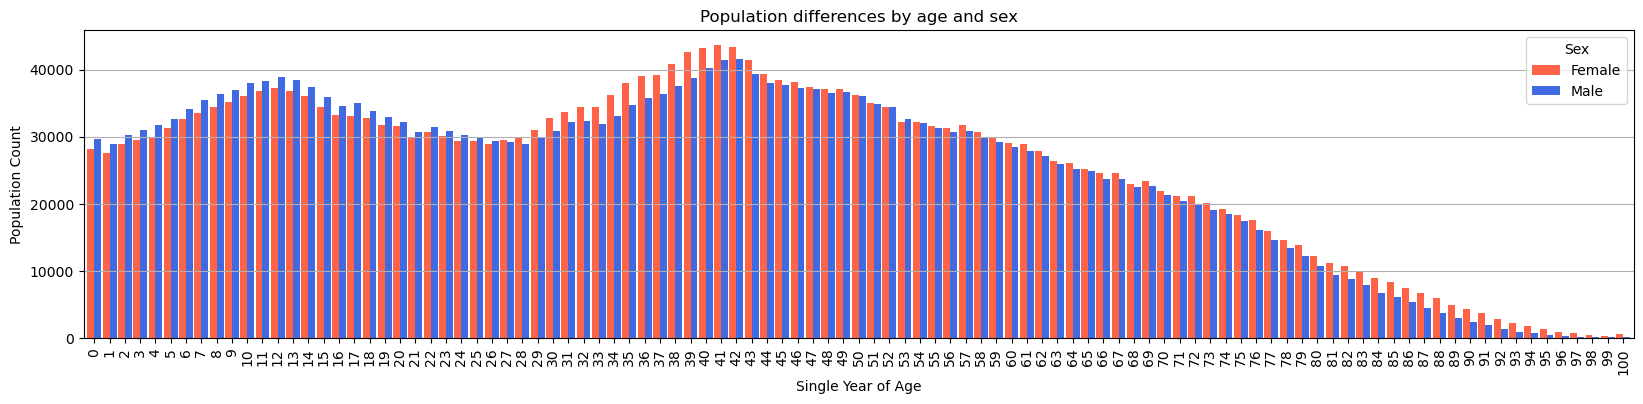

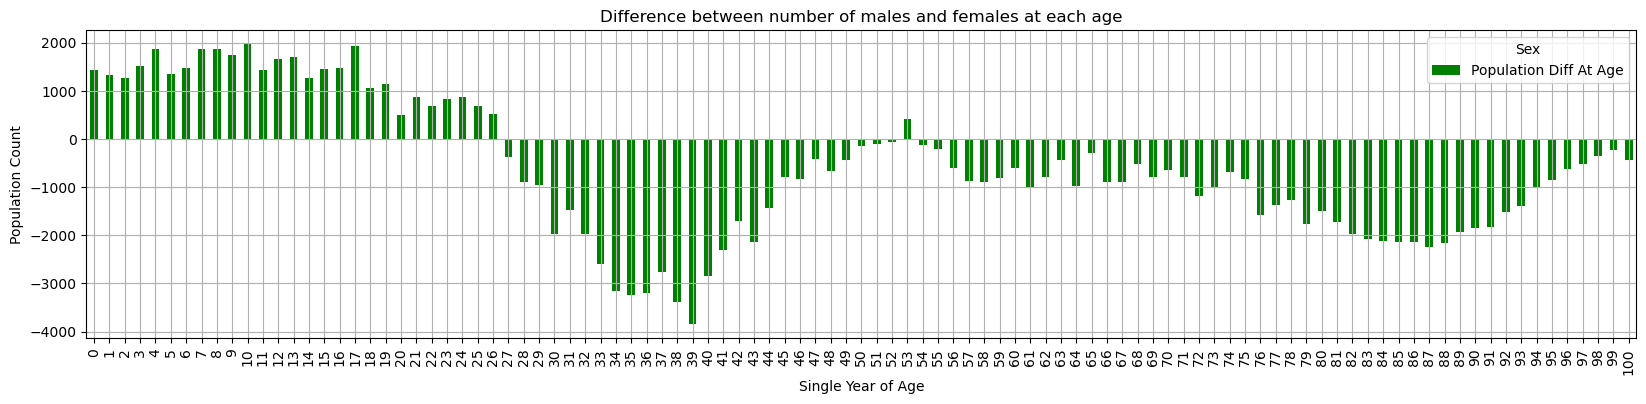

In [152]:
# Plot 1- create a clustered bar plot passing both sexes as Y axis  values
ax1 = df_analysis.plot.bar(y=['Female', 'Male'], width=0.9, color={"Male": "royalblue", "Female": "tomato"}, figsize=(20, 4))

# Add titles, labels, grid
ax1.set_title('Population differences by age and sex')   
ax1.set_ylabel('Population Count')
ax1.grid(axis='y')

# Plot 2 - create a separate bar plot to show the delta between male and female populations
ax2 = df_analysis.plot.bar(y=['Population Diff At Age'], color = 'green', figsize=(20, 4))

# Add titles, labels, grid
ax2.set_title('Difference between number of males and females at each age')   
ax2.set_ylabel('Population Count')
ax2.grid(True)


## Charts Intepretation
From the charts, we can observe the following population patterns by age and sex in Ireland:

**Overall Sex Differences**
- Males outnumber females from under **1 year up to age 26**.
- From **age of 27 onward**, females generally outnumber males.
    - The only exception is **age 53**, where the male population exceeds the female population.

**Population Differences Over 1,000**
- Male-dominant ages: under 1 to 19.
- Female-dominant ages: 30–44 and again 77-93.

**Population Differences Over 2,000**
- Females show a particularly strong dominance from ages 33–41 and again from ages 83-88.

**Population Differences Over 3,000**
- The strongest concentration of female dominance is between ages 34–39, with a peak at age 39, where the difference is approximately 3,800 individuals.

# Part 2 - People within 5 years of age analysis

### Filter for age band
To extract the populations within 5 years of age 35 (i.e., ages 30–40), I used the filtering approach based on guidance from [Geeks For Geeks](https://www.geeksforgeeks.org/python/filter-pandas-dataframe-with-multiple-conditions/?utm_source=chatgpt.com) tutorial on filtering with multiple conditions. 

In [153]:
# Create Age variable
age_35 = 35

# Filter for people within 5 years of that age
age_group = df_irl[(df_irl['Single Year of Age'] >= age_35 - 5) & 
                (df_irl['Single Year of Age'] <= age_35 + 5)]

# Show filtered age group
age_group

,Sex,Single Year of Age,Administrative Counties,VALUE
4256,Male,30,Ireland,30858
4288,Male,31,Ireland,32237
4320,Male,32,Ireland,32413
4352,Male,33,Ireland,31888
4384,Male,34,Ireland,33121
4416,Male,35,Ireland,34695
4448,Male,36,Ireland,35828
4480,Male,37,Ireland,36427
4512,Male,38,Ireland,37513
4544,Male,39,Ireland,38749


### Aggregate populations by sex
Use `groupby()` function for aggregation by sex for the new age group.

In [154]:
# Sum the population 
aggregated = age_group.groupby('Sex')['VALUE'].sum()

aggregated

Sex
Female    414506
Male      384030
Name: VALUE, dtype: int64

### Show the difference (Males - Females)

In [155]:
# Substruct aggregated female population from aggregated male population
population_difference = aggregated['Male'] - aggregated['Female']

population_difference

-30476

There are 30,476 more females than males in the population group within 5 years of age 35.

# Part 3 - Regions with biggest population difference

### Filter for individual regions
Modify the dataset to exclude "Ireland" from the *Administrative Counties* column so that only individual counties remain.

In [156]:
# Show counties other than Ireland
df_allregions = df[df['Administrative Counties'] != 'Ireland']

df_allregions.head(3)

,Sex,Single Year of Age,Administrative Counties,VALUE
3297,Male,0,Carlow County Council,346
3298,Male,0,Dublin City Council,3188
3299,Male,0,Dún Laoghaire Rathdown County Council,1269


### Filter for age group within 5 years of age 35

In [157]:
# Filter for people within 5 years of that age
age_group = df_allregions[(df_allregions['Single Year of Age'] >= age_35- 5) & 
                (df_allregions['Single Year of Age'] <= age_35 + 5)]

age_group

,Sex,Single Year of Age,Administrative Counties,VALUE
4257,Male,30,Carlow County Council,367
4258,Male,30,Dublin City Council,6163
4259,Male,30,Dún Laoghaire Rathdown County Council,1511
4260,Male,30,Fingal County Council,1888
4261,Male,30,South Dublin County Council,1819
...,...,...,...,...
7867,Female,40,Roscommon County Council,556
7868,Female,40,Sligo County Council,538
7869,Female,40,Cavan County Council,630
7870,Female,40,Donegal County Council,1293


### Pivot data
This time, we use `pivot_table()` with `aggfunc='sum'` to ensure that populations from the multiple ages within the age band are correctly aggregated.

In [158]:
# Pivot data for analysis
age_group_analysis = pd.pivot_table(age_group, values = 'VALUE', index=['Administrative Counties'], columns = 'Sex', aggfunc='sum')

age_group_analysis.head(3)

Sex,Female,Male
Administrative Counties,,
Carlow County Council,4774,4451
Cavan County Council,6150,5776
Clare County Council,8896,8085


### Calculate population difference 
Create a new column to show population diffrence, and convert the values to absolute numbers. Since the goal in Part 3 is to identify the largest population difference between sexes regardless of which sex is larger - using the absolute values ensures we capture the magnitude of the difference. Use [DataFrame.abs()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.abs.html) for conversion.

In [159]:
# Create a new column by substracting female populatios from male populations
# Convert the result to absolute values 
age_group_analysis['Population Difference'] = (age_group_analysis['Male'] - age_group_analysis['Female']).abs()

age_group_analysis.head(5)

Sex,Female,Male,Population Difference
Administrative Counties,,,
Carlow County Council,4774,4451,323
Cavan County Council,6150,5776,374
Clare County Council,8896,8085,811
Cork City Council,19750,18812,938
Cork County Council,26545,23706,2839


### Sort in descending order
Sort *Population Difference* column in decsending order so that the largest values appear at the top. This allows easy identification of regions with the biggest sex population differences. The sorting approach is based on a [Geek for Geeks](https://www.geeksforgeeks.org/python/sort-rows-or-columns-in-pandas-dataframe-based-on-values/) tutorial on sorting Pandas DataFrames by column values.

In [160]:
# Pass ascending=False argument to sort in descending order
age_group_sorted = age_group_analysis.sort_values(by='Population Difference', ascending=False)

age_group_sorted.head(5)

Sex,Female,Male,Population Difference
Administrative Counties,,,
Fingal County Council,29092,26150,2942
Cork County Council,26545,23706,2839
South Dublin County Council,26361,23637,2724
Kildare County Council,20602,18671,1931
Meath County Council,17715,15981,1734


From the top 5 rows we can see that the largest population difference of 2942 by sex was in Fingal County Council.

## End